In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [ ]:
#Defininig constants
h = 600e3 #satellite height in m
fc = 2e9 #Carrier frequency in Hz
c = 3e8  #speed of light (m/s)
k_B = 1.38e-23 #Boltzmann constant in J/K
R = 6371e3 #radius of earth in m
B = 30e6 #Bandwidth in Hz
eirp_d = 34 #EIRP density in dbW/MHz
T_ref = 290 #Reference temperature in Kelvin
P_bs = 43 #BS transmit power (dBm)
y_th = -3 #SINR threshold
N_u = 20 #Number of users per trial
G_ue = 0 #Gain at UE (dBi)
G_bs = 0 #Gain at BS (dBi)
L_bod = 3 #Signal absorbed by user's hand & head holding the phone (dB)
nf = 7 #Noise from the UE receiver electronics
K = 2000 #Number of Monte Carlo simulations
d_min = 35 #Minimum BS-UE distance
r_ue = 5e3 #UE radius in m
k_dB = -228.6 #Boltzmann constant in dBW/K/Hz
L_scint = 0.5 #Ionoshperic scintillation
u_dense = 50 #no of users using terrestrial link per km^2
B_total = 300e6 #total terrestrial operator bandwidth (Hertz)


In [ ]:

#Slant height
def slant_height(h, theta):
  theta = np.deg2rad(theta)
  d = -R*np.sin(theta)+np.sqrt((R*np.sin(theta))**2+(R+h)**2-R**2)
  return d

#Free Space Path loss
def FSPL(d, fc):
  fspl = 20*np.log10(d)+20*np.log10(fc)+20*np.log10(4*np.pi/c)
  return fspl

#Satellite signal
def satellite_signal(h, theta, fc, B, eirp_d, env):
  d = slant_height(h,theta)
  fspl = FSPL(d,fc)
  EIRP = eirp_d+10*np.log10(B/(1e6))
  if env == 'urban':
    L_shad = 6
  else:
    L_shad = 2
  T_rx = 290*((10**(nf/10))-1) #Receiver Noise
  T_sys = 290 + T_rx
  g_over_t = G_ue-L_bod-(10*np.log10(T_sys))
  CNR = EIRP - fspl - L_shad + g_over_t - L_scint -k_dB - (10*np.log10(B))
  N = 10*np.log10(k_B*T_sys*B)+30
  S = CNR + N
  # print(f"EIRP: {EIRP}")
  # print(f"FSPL: {fspl}")
  # print(f"L_shadow: {L_shad}")
  # print(f"G/T: {g_over_t}")
  # print(f"k_dB: {k_dB}")
  # print(f"BW_dBHz: {10 * np.log10(B)}")
  # print(f"CNR: {CNR}")
  # print(f"N: {N}")
  # print(f"S: {S}")
  return S, N, CNR

In [ ]:
#Generating basestations
def baseStations(b_dense, r_ue):
  b_dense = b_dense/1000000 #Convert from per km^2 to m^2
  area = np.pi*r_ue**2
  N_bs = b_dense*area
  Ne_bs = np.random.poisson(N_bs)
  if Ne_bs <= 0:
    return np.array([]), np.array([])
  dist = r_ue*np.sqrt(np.random.uniform(0, 1, Ne_bs))
  theta = np.random.uniform(0, 2*np.pi, Ne_bs)
  x = dist*np.cos(theta)
  y = dist*np.sin(theta)
  return x, y


#Generate users
def users(N_u,r_ue):
  dist = r_ue*np.sqrt(np.random.uniform(0, 1, N_u))
  angle = np.random.uniform(0, 2*np.pi, N_u)
  x = dist*np.cos(angle)
  y = dist*np.sin(angle)
  return x, y


# Calculates the fraction of BSs interfering on the shared satellite channel
def activity_factor(b_dense, u_dense, B, B_total):
  c0 = 3.5
  kappa = b_dense / u_dense
  pa = 1 / (1 - (1 + 1 / (c0 * kappa))**(-c0))
  pa = pa * (B / B_total)
  return pa

In [ ]:
#Path Loss
def path_loss(distances, fc, env):
  f_g = fc/1e9
  d = np.maximum(distances,10)
  pl_los = 28 + 22 * np.log10(d) + 20 * np.log10(f_g)
  pl_nlos = 13.54 + 39.08 * np.log10(d) + 20 * np.log10(f_g)
  if env == 'urban':
    d_bp = 50
  else:
    d_bp = 200
  p_los = np.minimum(d_bp / d, 1)
  is_los = np.random.uniform(0, 1, len(d)) < p_los
  pl = np.where(is_los, pl_los, pl_nlos)
  return pl, is_los


In [ ]:
#Calculating Interference
def interference(ue_x, ue_y, bs_x, bs_y, P_bs, G_bs, fc, env):
    if len(bs_x) == 0:
        return 0
    dx = bs_x - ue_x
    dy = bs_y - ue_y
    distances = np.sqrt(dx**2 + dy**2)
    distances = np.maximum(distances, d_min)
    pl, is_los = path_loss(distances, fc, env)
    fading = np.where(is_los, np.random.noncentral_chisquare(2, 20, len(distances)) / 22, np.random.exponential(1.0, len(distances)))
    rx_dbm = P_bs + G_bs - pl
    rx_mw = 10**(rx_dbm / 10) * fading
    total_mw = np.sum(rx_mw)
    return total_mw

In [ ]:
# Simulates one random deployment of BSs and UEs and checks coverage for each UE
def run_trial(N_u,  r_ue, b_dense, signal_dbm, noise_dbm, P_bs, G_bs, fc, env, y_th):
    ue_x, ue_y = users(N_u, r_ue)
    bs_x, bs_y = baseStations(b_dense, r_ue)
    S = 10**(signal_dbm / 10)
    N = 10**(noise_dbm / 10)
    threshold = 10**(y_th / 10)
    covered = 0
    sinr_values = []
    for u in range(N_u):
        I = interference(ue_x[u], ue_y[u], bs_x, bs_y, P_bs, G_bs, fc, env)
        sinr = S / (I + N)
        sinr_db = 10 * np.log10(sinr) if sinr > 0 else -50
        sinr_values.append(sinr_db)
        if sinr > threshold:
            covered += 1
    return covered, N_u, sinr_values

In [ ]:
# Repeats run_trial K times and returns the fraction of UEs with SINR above threshold
def run_sim(K, N_u, b_dense, h, theta, fc, B, eirp_d, env, y_th, P_bs, G_bs):
    signal_dbm, noise_dbm, cnr = satellite_signal(h, theta, fc, B, eirp_d, env)
    pa= activity_factor(b_dense, u_dense, B, B_total)
    eff_dense = pa*b_dense
    total_covered = 0
    total_ues = 0
    all_sinr = []
    for t in range(K):
        covered, n_total, sinr_vals = run_trial(N_u, r_ue, eff_dense, signal_dbm, noise_dbm, P_bs, G_bs, fc, env, y_th)
        total_covered += covered
        total_ues += n_total
        all_sinr.extend(sinr_vals)
    p_cov = total_covered / total_ues
    return p_cov, np.array(all_sinr), cnr

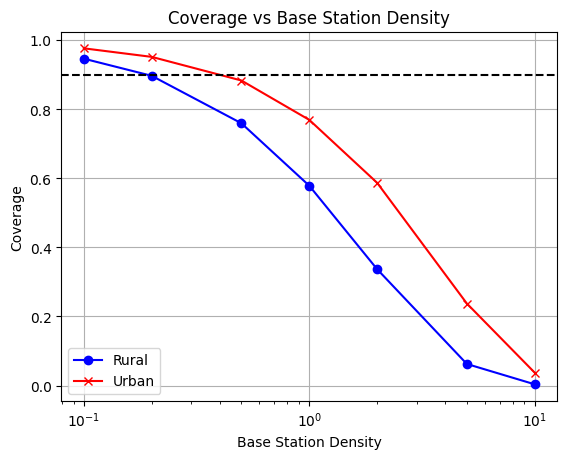

In [ ]:
#Coverage vs Base Station density -- Plot 1
rural_cov=[]
urban_cov=[]
theta = 30
densities = [0.1, 0.2, 0.5, 1, 2, 5, 10]
for env, cov in [('rural',rural_cov), ('urban',urban_cov)]:
  for i in densities:
    p_cov, _, _ = run_sim(K, N_u, i, h, theta, fc, B, eirp_d, env, y_th, P_bs, G_bs)
    cov.append(p_cov)
plt.plot(densities, rural_cov, label='Rural',color='blue',marker='o')
plt.plot(densities, urban_cov, label='Urban',color='red',marker='x')
plt.xscale('log')
plt.axhline(y=0.9, linestyle='--', color='black')
plt.xlabel('Base Station Density')
plt.ylabel('Coverage')
plt.title('Coverage vs Base Station Density')
plt.legend()
plt.grid(True)
plt.show()

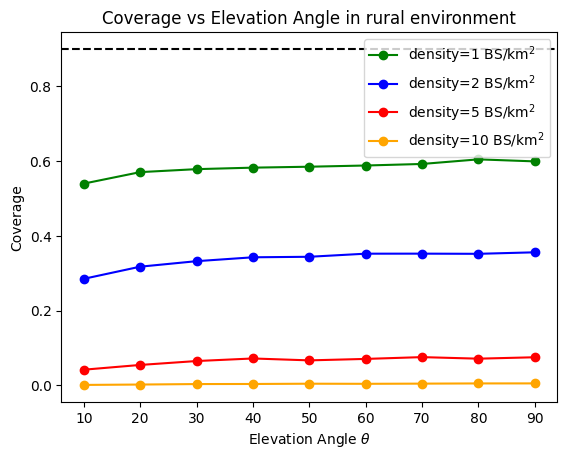

In [ ]:
#Coverage vs Elevation Angle -- Plot 2
theta = [10, 20, 30, 40, 50, 60, 70, 80, 90]
densities = [1, 2, 5, 10]
colors = ['green','blue','red','orange']
for i, color in zip(densities, colors):
  rural_cov=[]
  for j in theta:
    p_cov, _, _ = run_sim(K, N_u, i, h, j, fc, B, eirp_d, 'rural', y_th, P_bs, G_bs)
    rural_cov.append(p_cov)
  plt.plot(theta, rural_cov, label=f'density={i} BS/km$^2$',color=color, marker='o')
plt.axhline(y=0.9, linestyle='--', color='black')
plt.xlabel(r'Elevation Angle $\theta$')
plt.ylabel('Coverage')
plt.title('Coverage vs Elevation Angle in rural environment')
plt.legend()
plt.show()
